# **Raporti — LAB12:**
## **Lënda:** Hyrje në Laborator
## **Kodi i laboratorit:** LAB12
## **Titulli:** Hartëzimi i Fushës Magnetike
## **Studentja:** Albana Hoxha
## **Grupi:** 1
## **Data e zhvillimit të laboratorit:** 03-06-2026
## **Data e dorëzimit:** 10-06-2026
## **Pedagogu:** Ervin Kafexhiu

## **1. Qëllimi**

Qëllimi i këtij laboratori është të studiohet shpërndarja hapësinore e fushës magnetike duke kryer matje në pika të ndryshme të një zone të caktuar dhe duke ndërtuar një paraqitje 2D të intensitetit të saj. Për këtë përdoret magnetometri i integruar në telefon për të regjistruar komponentët  $B_x$, $B_y$, $B_z$. Të dhënat e mbledhura përpunohen në Python dhe përdoren për të krijuar vizualizime që tregojnë ndryshimet e fushës në hapësirë.

Ky laborator nuk synon matje me saktësi të lartë instrumentale, por ka si qëllim kryesor kuptimin praktik të mënyrës se si një madhësi fizike që ndryshon sipas pozicionit mund të matet, strukturohet në një rrjetë dhe përfaqësohet grafikisht në formë harte.


## **2. Teoria**
### 2.1 Fusha magnetike

Fusha magnetike është një madhësi vektoriale që ka si drejtim ashtu edhe madhësi në çdo pikë të hapësirës. Në sistemin ndërkombëtar (SI) ajo matet në tesla ($T$). Në aplikimet praktike, veçanërisht në matjet me smartphone, përdoret shpesh njësia mikrotesla:
$$ 1 \, \mu\text{T} = 10^{-6} \, \text{T} $$
Magnetometri i telefonit regjistron tre komponentët e fushës magnetike përgjatë boshteve të pajisjes:  $B_x$, $B_y$, $B_z$, të shprehura në mikrotesla ($\mu\text{T}$). Në sistemet Android, këto matje jepen sipas orientimit të telefonit në hapësirë.
Intensiteti total i fushës magnetike llogaritet me formulën:
$$ B = \sqrt{B_x^2 + B_y^2 + B_z^2} $$

Kjo madhësi përfaqëson vlerën që përdoret kryesisht për analizën dhe ndërtimin e hartave në këtë laborator.

### 2.2 Fusha magnetike e Tokës

Në mungesë të burimeve të tjera magnetike, magnetometri i telefonit mat kryesisht fushën magnetike të Tokës. Kjo fushë ka një intensitet tipik në rendin e dhjetëra mikrotesla, por vlera e saj ndryshon sipas vendndodhjes gjeografike dhe kushteve lokale.

Modele globale si World Magnetic Model përdoren për përshkrimin dhe parashikimin e fushës gjeomagnetike. Versioni më i fundit, WMM2025, është publikuar në dhjetor 2024 dhe përdoret si referencë deri në fund të vitit 2029.

Në këtë laborator, fusha magnetike e Tokës nuk analizohet në mënyrë të detajuar, por shërben si sfond mbi të cilin identifikohen ndryshimet lokale të matjeve.

### 2.3 Magnetometri i telefonit

Telefonat inteligjentë përmbajnë magnetometër të integruar, i cili përdoret kryesisht për aplikacione si busulla dhe orientimi në hapësirë. Përmes aplikacioneve si phyphox, është e mundur të aksesohen të dhënat e papërpunuara të sensorit të fushës magnetike.

Sipas dokumentimit të phyphox, magnetometri është një sensor i ndjeshëm, por vlerat absolute mund të kenë devijime për shkak të ndikimeve të brendshme të pajisjes, kalibrimit automatik dhe objekteve metalike përreth.

Për këtë arsye, në këtë laborator magnetometri përdoret kryesisht për:

analizë të ndryshimeve relative të fushës,
ndërtim hartash hapësinore 2D,
krahasim midis pikave të ndryshme të matjes,
identifikim të anomalive magnetike.

Qëllimi nuk është matja absolute me saktësi të lartë, por kuptimi praktik i shpërndarjes së fushës në hapësirë.

## **3. Aparatura / Software**

* Telefon inteligjent me magnetometër.
* Aplikacion për regjistrim të fushës magnetike.
* Një magnet i vogël permanent.
* Letër A3/A2, karton ose tavolinë me rrjetë të vizatuar.
* Vizore ose metër.
* Laptop me Python/Jupyter.
* phyphox — Magnetic field (Ky aplikacion lexon komponentët e magnetometrit dhe lejon eksportimin e të dhënave. Eksperimenti “Magnetic field” përdor magnetometrin dhe jep komponentët e fushës magnetike në kohë.)

## **4.Të dhënat**

Laboratori ndahet në katër pjesë:

**Eksperimenti A**: Matja e fushës magnetike ambientale.

**Eksperimenti B**: Hartëzimi 1D i fushës pranë një magneti.

**Eksperimenti C**: Hartëzimi 2D i fushës pranë një magneti.

### 4.1.Eksperimenti A - Matja e fushës magnetike ambientale:

Në këtë eksperiment telefoni u vendos larg magnetëve dhe objekteve metalike. Matja u regjistrua për rreth 60 sekonda me qëllim përcaktimin e fushës magnetike të sfondit, e cila do të përdoret si referencë në eksperimentet e tjera.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/B_background.")

print(df.head())
print(df.columns)


   Time (s)  Magnetic Field x (µT)  Magnetic Field y (µT)  \
0  0.011162              12.547037              17.666250   
1  0.021150              12.666079              17.773001   
2  0.031138              12.621241              17.718252   
3  0.041126              12.707248              17.764864   
4  0.051114              12.642980              17.825876   

   Magnetic Field z (µT)  Absolute field (µT)  
0             -40.458061            45.895308  
1             -40.401054            45.918997  
2             -40.330986            45.823800  
3             -40.311180            45.848182  
4             -40.469200            45.993075  
Index(['Time (s)', 'Magnetic Field x (µT)', 'Magnetic Field y (µT)',
       'Magnetic Field z (µT)', 'Absolute field (µT)'],
      dtype='str')


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_bg = pd.read_csv("data/B_background.")

Bx = df_bg["Magnetic Field x (µT)"]
By = df_bg["Magnetic Field y (µT)"]
Bz = df_bg["Magnetic Field z (µT)"]

df_bg["B_uT"] = np.sqrt(Bx**2 + By**2 + Bz**2)

print("B mesatare =", df_bg["B_uT"].mean())
print("Devijimi standard =", df_bg["B_uT"].std(ddof=1))

B mesatare = 45.91327714544446
Devijimi standard = 0.17120268747019798


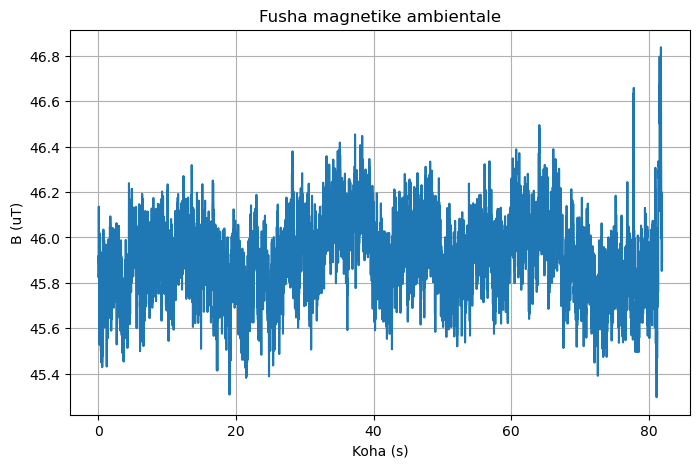

In [14]:
plt.figure(figsize=(8,5))

plt.plot(df_bg["Time (s)"], df_bg["B_uT"])

plt.xlabel("Koha (s)")
plt.ylabel("B (uT)")
plt.title("Fusha magnetike ambientale")
plt.grid(True)

plt.show()

### 4.2. Eksperimenti B — Hartëzimi 1D pranë një magneti

Qëllimi i këtij eksperimenti ishte të studiohej ndryshimi i fushës magnetike me largësinë nga magneti.

Magneti u vendos në qendër të zonës së matjes dhe matjet u kryen në pika të ndryshme përgjatë një vije të drejtë. Telefoni u mbajt me të njëjtin orientim në të gjitha matjet dhe në çdo pikë u regjistruan të dhëna për afërsisht 5 sekonda.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv("data/B_1D.csv")

print(df1.head())
print(df1.columns)

   Time (s)  Magnetic Field x (µT)  Magnetic Field y (µT)  \
0  0.026621               4.908796             -45.906120   
1  0.036610               4.942778             -46.112999   
2  0.046599               5.005033             -46.127846   
3  0.056587               5.211734             -46.197029   
4  0.066576               5.378362             -46.043537   

   Magnetic Field z (µT)  Absolute field (µT)  
0              -3.701401            46.315964  
1              -3.673912            46.522439  
2              -3.733536            46.548553  
3              -3.689575            46.636259  
4              -3.596451            46.495898  
Index(['Time (s)', 'Magnetic Field x (µT)', 'Magnetic Field y (µT)',
       'Magnetic Field z (µT)', 'Absolute field (µT)'],
      dtype='str')


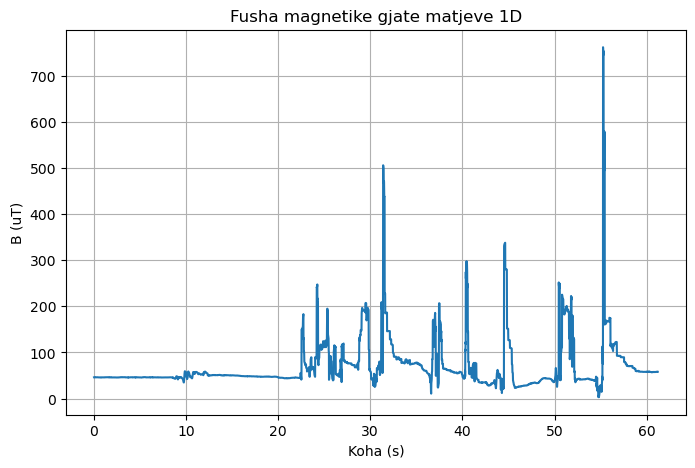

In [25]:
Bx = df1["Magnetic Field x (µT)"]
By = df1["Magnetic Field y (µT)"]
Bz = df1["Magnetic Field z (µT)"]

df1["B_uT"] = np.sqrt(Bx**2 + By**2 + Bz**2)

B_background = 45.91

df1["DeltaB_uT"] = df1["B_uT"] - B_background
plt.figure(figsize=(8,5))

plt.plot(df1["Time (s)"], df1["B_uT"])

plt.xlabel("Koha (s)")
plt.ylabel("B (uT)")
plt.title("Fusha magnetike gjate matjeve 1D")
plt.grid(True)

plt.show()

In [23]:
print("B min =", df1["B_uT"].min())
print("B max =", df1["B_uT"].max())
print("B mesatare =", df1["B_uT"].mean())

B min = 3.0009097777335842
B max = 761.36658850635
B mesatare = 70.1429852938186


### 4.3.Eksperimenti C — Hartëzimi 2D i fushës magnetike

Qëllimi i këtij eksperimenti ishte ndërtimi i një harte 2D të fushës magnetike pranë një magneti.

U përdor një rrjetë 5 × 5 me hap prej 5 cm midis pikave matëse. Magneti u vendos në qendër të rrjetës dhe telefoni u mbajt me të njëjtin orientim gjatë të gjitha matjeve. Në secilën pikë u regjistruan të dhëna për afërsisht 5 sekonda.

In [24]:
df2 = pd.read_csv("data/B_map_2D.csv")

print(df2.head())
print(df2.columns)

   Time (s)  Magnetic Field x (µT)  Magnetic Field y (µT)  \
0  0.006275              18.667723               8.726961   
1  0.016263              18.678205               8.740450   
2  0.026251              18.602446               8.793825   
3  0.036239              18.621058               8.831779   
4  0.046227              18.810999               8.695784   

   Magnetic Field z (µT)  Absolute field (µT)  
0             -37.520958            42.807313  
1             -37.514565            42.809034  
2             -37.556541            42.823780  
3             -37.549767            42.833738  
4             -37.601463            42.934140  
Index(['Time (s)', 'Magnetic Field x (µT)', 'Magnetic Field y (µT)',
       'Magnetic Field z (µT)', 'Absolute field (µT)'],
      dtype='str')


In [26]:
Bx = df2["Magnetic Field x (µT)"]
By = df2["Magnetic Field y (µT)"]
Bz = df2["Magnetic Field z (µT)"]

df2["B_uT"] = np.sqrt(Bx**2 + By**2 + Bz**2)

B_background = 45.91

df2["DeltaB_uT"] = df2["B_uT"] - B_background
print("B min =", df2["B_uT"].min())
print("B max =", df2["B_uT"].max())
print("B mesatare =", df2["B_uT"].mean())
print("Devijimi standard =", df2["B_uT"].std(ddof=1))

B min = 40.75155657209853
B max = 43.48310833198455
B mesatare = 41.54196449232502
Devijimi standard = 0.3756980838335389


In [27]:
print(len(df2))

6726


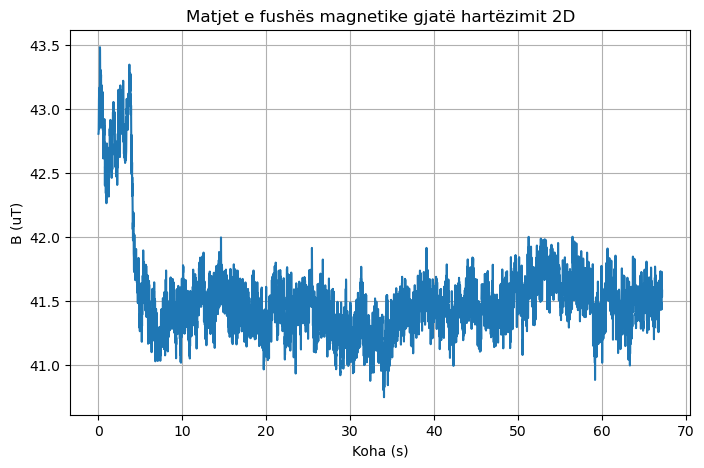

In [29]:
plt.figure(figsize=(8,5))

plt.plot(df2["Time (s)"], df2["B_uT"])

plt.xlabel("Koha (s)")
plt.ylabel("B (uT)")
plt.title("Matjet e fushës magnetike gjatë hartëzimit 2D")
plt.grid(True)

plt.show()

## 5.Analiza e të dhënave

**5.1**Nga matjet e realizuara për rreth 60 sekonda u përcaktua fusha magnetike e ambientit në zonën e matjes. Intensiteti total u llogarit duke përdorur komponentët  $B_x$, $B_y$, $B_z$.
Vlera mesatare e fushës magnetike u përdor si sfond për eksperimentet e mëtejshme. Grafiku tregon se matjet janë relativisht të qëndrueshme në kohë, ndërsa ndryshimet e vogla vijnë nga zhurma e sensorit dhe ndikimet e mjedisit përreth.

Nga analiza e të dhënave u gjet:

B mesatare = 45.91 µT

Devijimi standard = 0.17 µT

Vlera mesatare e fushës magnetike ambientale rezultoi afërsisht 45.91 uT, e cila është në përputhje me rendin e madhësisë së fushës magnetike të Tokës. Devijimi standard relativisht i vogël tregon se sensori ishte i qëndrueshëm gjatë matjes dhe se kushtet e eksperimentit nuk ndryshuan ndjeshëm gjatë regjistrimit.

 **5.2**
B min = 3 µT

B max = 761.366 µT

B mesatare = 70.14 µT

Rezultatet tregojnë se intensiteti i fushës magnetike ndryshon në varësi të pozicionit të telefonit ndaj magnetit. Vlerat më të larta u regjistruan në pikat më afër magnetit, ndërsa me rritjen e largësisë fusha magnetike u zvogëlua gradualisht.

Kjo sjellje është në përputhje me teorinë e fushës magnetike të një magneti, sipas së cilës intensiteti i fushës zvogëlohet me largësinë nga burimi.

 **5.3**
 B min = 40.75 µT
 
B max = 43.48 µT

B mesatare =41.54 µT

Devijimi standard = 0.375 µT

Vlera më e lartë u regjistrua në pikat më afër magnetit. Kjo tregon ndikimin e qartë të magnetit në fushën magnetike të matur.

## 6.Tabela Përmbledhëse

| Eksperimenti     | B min [$\mu\text{T}$] | B max [$\mu\text{T}$] |  B mes  [$\mu\text{T}$] |
|------------------|------------------------|------------------------|--------------------------|
| Fusha ambientale       |                   | 45.91                 | 45.91                    | 
| Magneti 1D       | 3                  | 761.36                 | 70.14                  | 
| Harta 2D         | 4.75                   | 43.48                 | 41.54                   | 

## 7.Diskutim

### Përgjigje ndaj pyetjeve

#### 1. Ku është fusha më e madhe?
Fusha magnetike është më e madhe në pikat më afër magnetit. Me rritjen e largësisë nga magneti, intensiteti i fushës zvogëlohet.

#### 2. A është harta simetrike?
Harta është afërsisht simetrike rreth magnetit, por mund të ketë devijime të vogla për shkak të gabimeve eksperimentale, orientimit të telefonit dhe ndikimeve të mjedisit përreth.

#### 3. A ndikon orientimi i telefonit?
Po. Komponentët \(B_x\), \(B_y\) dhe \(B_z\) varen nga orientimi i telefonit. Për këtë arsye orientimi duhet të mbahet sa më konstant gjatë matjeve.

#### 4. A vërehet qartë ndikimi i magnetit mbi fushën e Tokës?
Po. Pranë magnetit vlerat e fushës magnetike janë dukshëm më të larta se sfondi magnetik, duke treguar qartë ndikimin e magnetit.

#### 5. Sa të qëndrueshme janë matjet në kohë?
Matjet janë relativisht të qëndrueshme. Luhatjet e vogla që vërehen në grafikë lidhen kryesisht me zhurmën e sensorit dhe faktorë të tjerë të ambientit.

#### 6. A është më e kuptueshme harta e \(B\) apo e \(\Delta B\)?
Harta e \(\Delta B\) është zakonisht më e kuptueshme, sepse tregon vetëm ndryshimin nga sfondi magnetik dhe nxjerr më qartë në pah efektin e magnetit.

#### 7. Cilat janë burimet kryesore të gabimit?
Burimet kryesore të gabimit janë:
- orientimi jo i njëjtë i telefonit,
- pozicioni i pasaktë i pikave të matjes,
- vendndodhja e panjohur e magnetometrit brenda telefonit,
- objektet metalike ose pajisjet elektronike në afërsi,
- zhurma e sensorit.

#### 8. Pse nuk duhet t’i besojmë verbërisht vlerës absolute të magnetometrit të telefonit?
Magnetometri i telefonit nuk është një instrument laboratorik i kalibruar me saktësi të lartë. Vlerat mund të ndikohen nga gabimet e kalibrimit, ndërhyrjet elektromagnetike dhe karakteristikat e vetë sensorit.

#### 9. A duket sjellja 1D e fushës e ngjashme me rënien \(1/r^3\)?
Po, në mënyrë cilësore rezultatet tregojnë se fusha zvogëlohet shpejt me largësinë nga magneti, në përputhje me sjelljen e pritur të një dipoli magnetik, e cila afërsisht ndjek ligjin \(1/r^3\).


------

### Përgjigje ndaj pyetjeve

 1. Pse fusha magnetike është madhësi vektoriale?
* Fusha magnetike është madhësi vektoriale sepse ka si madhësi ashtu edhe drejtim. Për këtë arsye ajo përshkruhet me komponentët $B_x$, $B_y$, $B_z$.

 2. Çfarë përfaqësojnë $B_x$, $B_y$, $B_z$?
* $B_x$, $B_y$, $B_z$ përfaqësojnë komponentët e fushës magnetike sipas tre boshteve të koordinatave të telefonit. Këta komponentë përdoren për të llogaritur intensitetin total të fushës magnetike.

 3. Pse përdorim $B = \sqrt{B_x^2 + B_y^2 + B_z^2}$?
* Kjo formulë përdoret për të gjetur intensitetin total të fushës magnetike duke kombinuar të tre komponentët në një vlerë të vetme.

 4. Pse duhet matur sfondi magnetik?
* Matja e sfondit magnetik na lejon të dallojmë ndikimin e magnetit ose anomalive lokale nga fusha magnetike natyrore e Tokës.

 5. Cilat janë burimet kryesore të gabimit?
* Burimet kryesore të gabimit janë orientimi i telefonit, pozicioni i panjohur i magnetometrit brenda telefonit, objektet metalike në afërsi dhe zhurma e sensorit.

## 8. Përfundime

Në këtë laborator u përdor magnetometri i telefonit për matjen dhe analizimin e fushës magnetike në kushte të ndryshme. Fillimisht u mat fusha magnetike ambientale, më pas u studiua ndryshimi i saj në varësi të largësisë nga magneti dhe u realizua hartëzimi i fushës magnetike në një rrjet 2D.

Rezultatet treguan se intensiteti i fushës magnetike varet nga pozicioni ndaj magnetit. Vlerat më të larta u regjistruan në pikat më afër magnetit, ndërsa me rritjen e largësisë fusha magnetike u zvogëlua. Harta 2D tregoi qartë shpërndarjen hapësinore të fushës magnetike dhe identifikoi zonat me intensitet më të lartë.

Matjet e sfondit magnetik rezultuan relativisht të qëndrueshme gjatë kohës së regjistrimit, duke treguar funksionim të qëndrueshëm të sensorit dhe kushte të përshtatshme matjeje. Gjithashtu u vu re se orientimi i telefonit, objektet metalike në afërsi dhe zhurma e sensorit mund të ndikojnë në rezultatet e marra.

Laboratori tregoi se magnetometri i telefonit mund të përdoret me sukses për studimin dhe vizualizimin e fushës magnetike. Edhe pse nuk është një instrument profesional dhe ka kufizime në saktësi, ai ofron rezultate të dobishme për të kuptuar sjelljen e fushave magnetike dhe faktorët që ndikojnë në matjet eksperimentale.